# Cliff Walking

[Image of Environment](https://gymnasium.farama.org/_images/cliff_walking.gif)

The environment is a 4x12 grid. The agent starts at the bottom-left corner and needs to reach the goal at the bottom-right corner. The catch is the row of "cliff" cells right between them.

[Documentation](https://gymnasium.farama.org/environments/toy_text/cliff_walking/#:~:text=Cliff%20walking%20involves%20crossing%20a,10%5D.)

In [1]:
# Import all relevant packages

import gymnasium as gym
import pygame
import sys
import numpy as np
from datetime import datetime


/Users/tahsinhasemaonim/.local/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## Human play
Play as human to familiarize with the environment.

Controls are as Follows:

- Up: w
- Down: s
- Left: a
- Right: d

In [3]:
pygame.init()

env = gym.make("CliffWalking-v1", render_mode="rgb_array")
clock = pygame.time.Clock()

env.reset()
frame = env.render()
height, width, _ = frame.shape
screen = pygame.display.set_mode((width, height))


state, info = env.reset()

running = True
terminated = False
truncated = False

while running and not (terminated or truncated):

    action = None

    for event in pygame.event.get():

        if event.type == pygame.QUIT:
            running = False

        elif event.type == pygame.KEYDOWN:

            if event.key == pygame.K_w:
                action = 0

            elif event.key == pygame.K_d:
                action = 1

            elif event.key == pygame.K_s:
                action = 2

            elif event.key == pygame.K_a:
                action = 3

            elif event.key == pygame.K_q:
                running = False

    if action is not None:

        state, reward, terminated, truncated, info = env.step(action)

    frame = env.render()


    if frame is not None:

        surface = pygame.image.frombuffer(
            frame.tobytes(),
            frame.shape[1::-1],
            "RGB"
        )

        screen.blit(surface, (0, 0))
        pygame.display.flip()

    clock.tick(30)

pygame.event.pump()
pygame.display.flip()

env.close()
pygame.display.quit()
pygame.quit()
sys.exit()

SystemExit: 

/Users/tahsinhasemaonim/.local/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3558: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## Solving the Game

There are multiple approaches we can take to solve this problem. Both tabular and functional methods can help us solve this. For The tabular approach, we can consider Monte Carlo, TD-Methods, Q-Learning Methods, and even the Double-Q Learning Methods. We shall try each of the methods to gain better uderstanding of the core concepts of RL. Since this is a finite state space environment and the states are markov, we can apply many MDP based RL methods - making this the perfect environment to take an academic approach to RL methods.

### Monte Carlo Methods (Epsilon)

Our First tabular attempt at solving this environment will be the popular Monte Carlo Control. We will need a Table to store all state-action-value paris for the utility of each environment. 

#### Note on inspiration for Action-Value-Pairs
This is a deterministic environment where we know with 100% probability that the intended action will be performed with 100% accuracy. However, not all environments are deterministic but stoichastic. Therefore, we generalize to using state-action-value pairs instead of state-action-reward pairs. This way if the environment is deterministic, our model will merely adjust the value accordingly. Say we set gamma to 1. Say at state S, we take action a - it has 10% chance of going to S1 (Value 20) and 90% chance of going to s2 (Value 1). Then our action-state-value table will learn that S-a will have total value of 0.1 * 20 + 0.9 * 1 = 2.9, given enough trial are performed.

### Core Update Equation for Monte Carlo Control

The core quation relies on 

$$Q(s, a) \leftarrow Q(s, a) + \alpha \Big( G_t - Q(s, a) \Big)$$

$$V(s) \leftarrow V(s) + \alpha \Big( G_t - V(s) \Big)$$

$Q(s, a)$: The current estimated value of taking action $a$ in state $s$.

$\alpha$: The learning rate (step size). 

$G_t$: The actual cumulative discounted return received after time step $t$:

$$G_t = \sum_{k=0}^{T-t-1} \gamma^k R_{t+k+1}$$



Note: Here $\small( G_t - Q(s, a) \small)$ is Monte Carlo Error -  the difference between current estimate and actual reward.

### The Epsilon Greedy Policy
When we want to balance exploration and exploitation in reinforcement learning, we can use the epsilon-greedy policy. This policy selects the action with the highest estimated value (exploitation) with probability 1 - epsilon, and selects a random action (exploration) with probability epsilon. The mathematical representation of the epsilon-greedy policy is as follows:

$$\pi(a|s) = \begin{cases} 1 - \epsilon + \frac{\epsilon}{|A(s)|} & \text{if } a = \arg\max_{a'} Q(s, a') \\ \frac{\epsilon}{|A(s)|} & \text{if } a \neq \arg\max_{a'} Q(s, a') \end{cases}$$
                                                                                                                                                                         


Now that the Mathematical Foundations are out of the way, lets dive into implementation!

### On Policy Monte Carlo Control

In [2]:
# Setup
gemma = 0.9
epsilon = 0.1
alpha = 0.1
num_episodes = 5000
MAX_STEPS_PER_EPISODE = 500


env = gym.make("CliffWalking-v1", max_episode_steps=MAX_STEPS_PER_EPISODE)

action_space = np.arange(env.action_space.n)
observation_space = np.arange(env.observation_space.n)

q_table = np.zeros((len(observation_space), len(action_space)))
episode_lengths = []
episode_rewards = []
episode_durations = []
episode_avg_mc_error = []

In [3]:
# Monte Carlo Control with Exploring Starts

for episode in range(num_episodes):

    start_time = datetime.now()
    env.reset()

    # Array to store, State, Action, Reward for the current episode. WE use it to backtrack and update the Q-values at the end of the episode.
    episode_data = []
    terminated = False
    truncated = False

    state, info = env.reset()

    while not (terminated or truncated):

        # Epsilon-greedy action selection
        if np.random.rand() < epsilon:
            action = np.random.choice(action_space)
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        episode_data.append((state, action, reward))

        state = next_state

    # Calculate returns and update Q-values
    G = 0
    for state, action, reward in reversed(episode_data):
        G = gemma * G + reward
        q_table[state, action] += alpha * (G - q_table[state, action])

    # Average episode error for monitoring convergence
    Avg_MC_Episode_Error = np.mean([np.abs(G - q_table[state, action]) for state, action, reward in episode_data])
    episode_avg_mc_error.append(Avg_MC_Episode_Error)


    end_time = datetime.now()
    episode_duration = (end_time - start_time).total_seconds()
    episode_durations.append(episode_duration)
    episode_rewards.append(sum([reward for _, _, reward in episode_data]))
    episode_lengths.append(len(episode_data))


    if (episode + 1) % 10 == 0:
        print(f"Episode: {episode + 1}, Average MC Episode Error: {Avg_MC_Episode_Error:.4f}")
        print(f"Episode Duration: {episode_duration:.2f} seconds")
        print(f"Total Reward: {episode_rewards[-1]}, Episode Length: {episode_lengths[-1]}")
        

Episode: 10, Average MC Episode Error: 12.4816
Episode Duration: 0.00 seconds
Total Reward: -896, Episode Length: 500
Episode: 20, Average MC Episode Error: 0.2233
Episode Duration: 0.00 seconds
Total Reward: -500, Episode Length: 500
Episode: 30, Average MC Episode Error: 0.1481
Episode Duration: 0.00 seconds
Total Reward: -500, Episode Length: 500
Episode: 40, Average MC Episode Error: 3.6968
Episode Duration: 0.00 seconds
Total Reward: -599, Episode Length: 500
Episode: 50, Average MC Episode Error: 88.8892
Episode Duration: 0.00 seconds
Total Reward: -599, Episode Length: 500
Episode: 60, Average MC Episode Error: 0.1464
Episode Duration: 0.00 seconds
Total Reward: -500, Episode Length: 500
Episode: 70, Average MC Episode Error: 0.0298
Episode Duration: 0.00 seconds
Total Reward: -500, Episode Length: 500
Episode: 80, Average MC Episode Error: 0.0584
Episode Duration: 0.00 seconds
Total Reward: -500, Episode Length: 500
Episode: 90, Average MC Episode Error: 0.0165
Episode Duration

# Simulate

Since we ill be Simulating our Agents often, its worthwile to declare a helper method to simulate different agents.

In [ ]:
from utils import visualize_policy

policy_fn = lambda state: np.argmax(q_table[state])

visualize_policy(policy_fn, title="Trained Q-Learning Agent", max_episode_steps=100)


 Starting Evaluation: Trained Q-Learning Agent
Step=  1 | State=24 | Reward=  -1 | Total Reward=  -1 | Action=Up
Step=  2 | State=12 | Reward=  -1 | Total Reward=  -2 | Action=Up
Step=  3 | State=13 | Reward=  -1 | Total Reward=  -3 | Action=Right
Step=  4 | State=14 | Reward=  -1 | Total Reward=  -4 | Action=Right
Step=  5 | State= 2 | Reward=  -1 | Total Reward=  -5 | Action=Up
Step=  6 | State= 3 | Reward=  -1 | Total Reward=  -6 | Action=Right
Step=  7 | State=15 | Reward=  -1 | Total Reward=  -7 | Action=Down
Step=  8 | State=16 | Reward=  -1 | Total Reward=  -8 | Action=Right
Step=  9 | State= 4 | Reward=  -1 | Total Reward=  -9 | Action=Up
Step= 10 | State= 5 | Reward=  -1 | Total Reward= -10 | Action=Right
Step= 11 | State= 6 | Reward=  -1 | Total Reward= -11 | Action=Right
Step= 12 | State= 7 | Reward=  -1 | Total Reward= -12 | Action=Right
Step= 13 | State= 8 | Reward=  -1 | Total Reward= -13 | Action=Right
Step= 14 | State= 9 | Reward=  -1 | Total Reward= -14 | Action=Right

# Metrices

Its important to view how well our learning methods are working. So we monitor the MC Error, Average Rewards, Average Duration etc. and use graphs to visualize them.

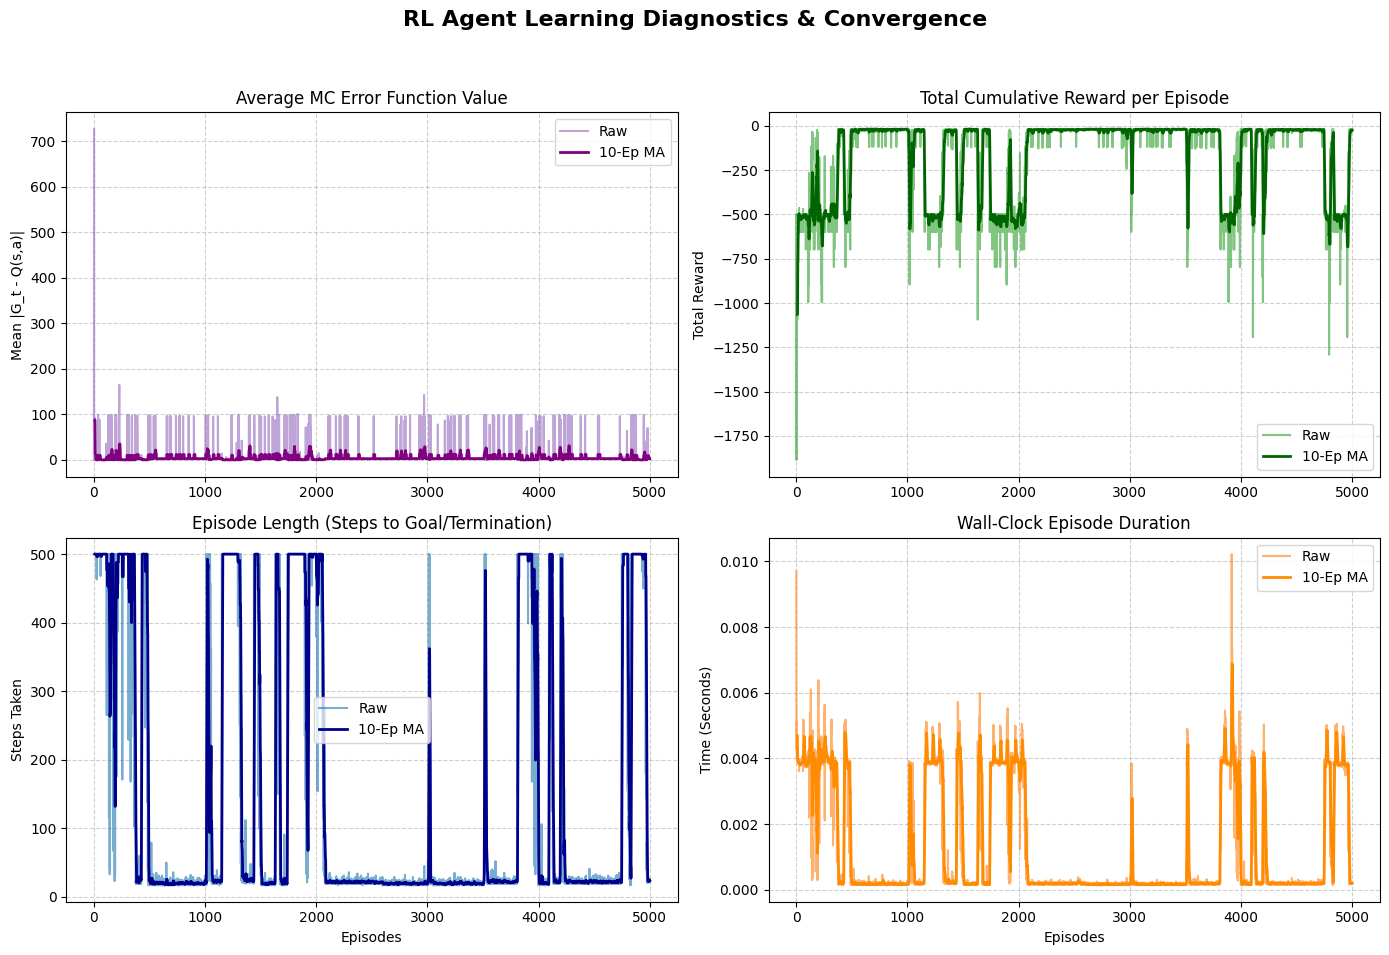

In [4]:
from utils import plot_learning_diagnostics, plot_smoothed_diagnostics

plot_learning_diagnostics(
    episode_avg_mc_error, episode_rewards, episode_lengths, episode_durations
)

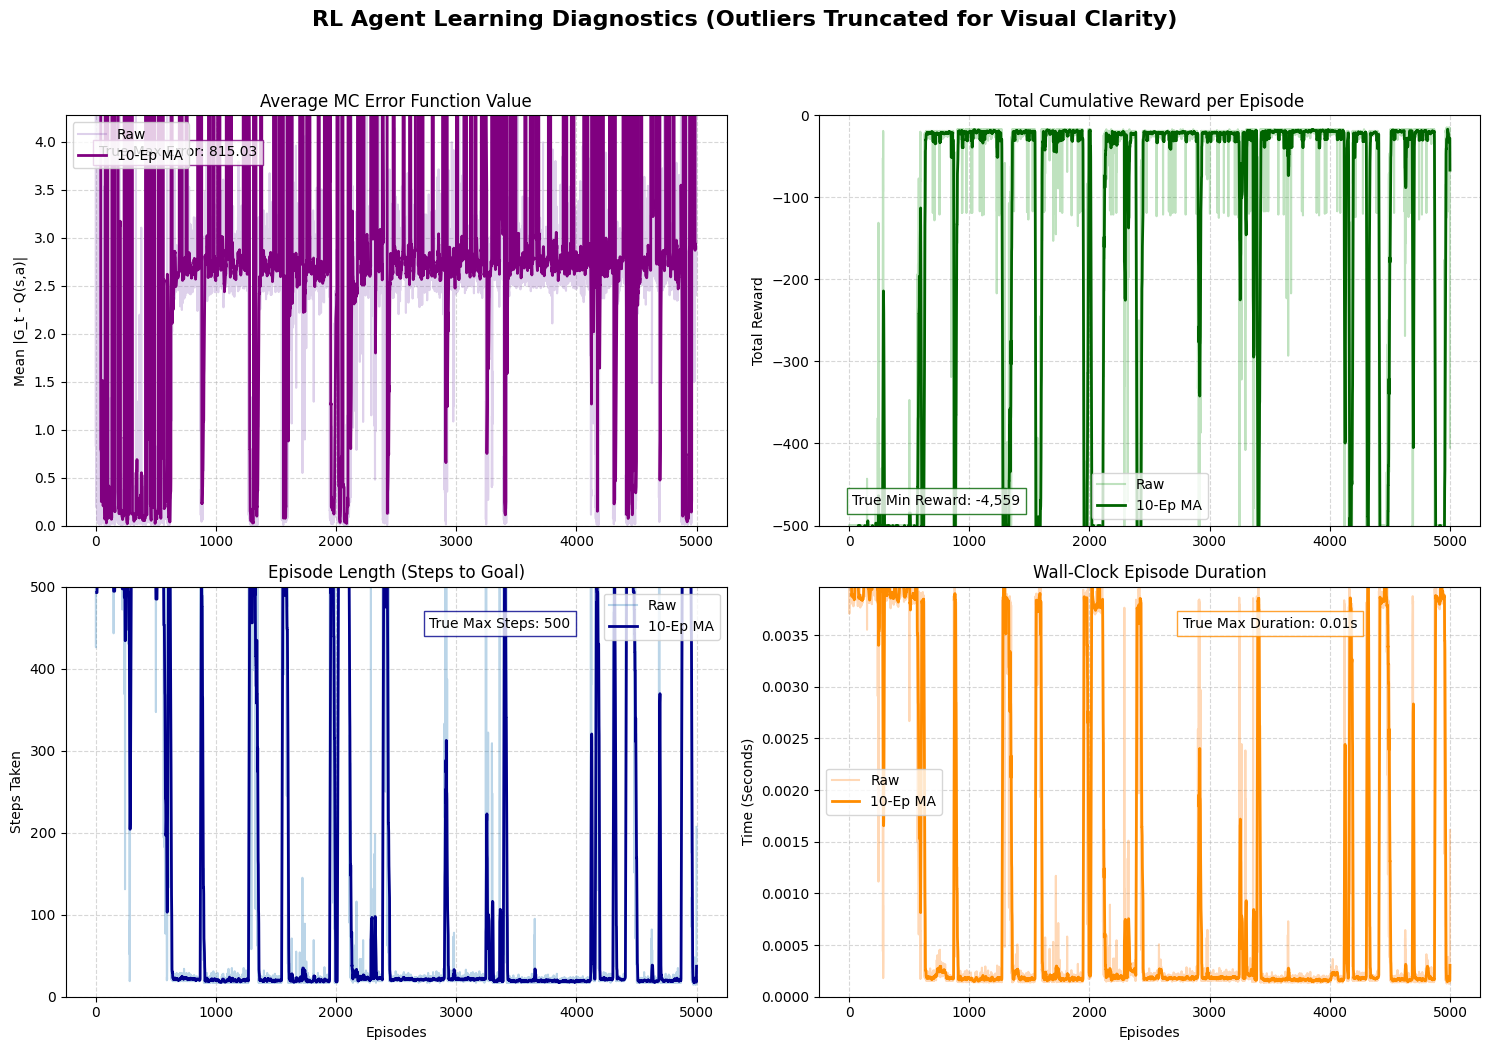

In [24]:
plot_smoothed_diagnostics(
    episode_avg_mc_error, episode_rewards, episode_lengths, episode_durations
)

## Comments

Our Mean MC Error seems to converge to 0 but then fluctuates out. It is because we are not decaying our epsilon policy. As the agent keeps learning, we should slowly decay the Epsilon, prioritizing exploitationg over exploration. Let's take a look how that can help!

### On-Policy MC Control (Epsilon Decay)

We will decay our epsilon so our agen prioritises Exploration intially then prioritises exploration! We will use clipped exponential epsilon decay:

$$\epsilon_{k+1} = \max(\epsilon_{min}, \epsilon_k \cdot d)$$

$\epsilon_k $ : Epsilon at step k.

$d$: The epsilon decay rate

In [54]:
# Constants and Hyperparameters
epsilon = 0.1
epsilon_decay_rate = 0.999
epsilon_min = 0.01

gemma = 0.9
alpha = 0.1
num_episodes = 5000
MAX_STEPS_PER_EPISODE = 500

seed = 42

env = gym.make("CliffWalking-v1", max_episode_steps=MAX_STEPS_PER_EPISODE)

action_space = np.arange(env.action_space.n)
observation_space = np.arange(env.observation_space.n)

q_table = np.zeros((len(observation_space), len(action_space)))
episode_lengths = []
episode_rewards = []
episode_durations = []
episode_avg_mc_error = []


In [55]:
# Monte Carlo Control with Exploring Epsilon Decay


#Define RNG with a fixed seed for reproducibility
rng = np.random.default_rng(seed=seed)


for episode in range(num_episodes):

    start_time = datetime.now()
    env.reset()

    # Array to store, State, Action, Reward for the current episode. WE use it to backtrack and update the Q-values at the end of the episode.
    episode_data = []
    terminated = False
    truncated = False

    state, info = env.reset()
    epsilon = max(epsilon * epsilon_decay_rate, epsilon_min)  # Decay epsilon after each episode

    while not (terminated or truncated):

        # Epsilon-greedy action selection
        if rng.random() < epsilon:
            action = rng.choice(action_space)
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        episode_data.append((state, action, reward))

        state = next_state

    # Calculate returns and update Q-values
    G = 0
    for state, action, reward in reversed(episode_data):
        G = gemma * G + reward
        q_table[state, action] += alpha * (G - q_table[state, action])

    # Average episode error for monitoring convergence
    Avg_MC_Episode_Error = np.mean([np.abs(G - q_table[state, action]) for state, action, reward in episode_data])
    episode_avg_mc_error.append(Avg_MC_Episode_Error)


    end_time = datetime.now()
    episode_duration = (end_time - start_time).total_seconds()
    episode_durations.append(episode_duration)
    episode_rewards.append(sum([reward for _, _, reward in episode_data]))
    episode_lengths.append(len(episode_data))


    if (episode + 1) % 10 == 0:
        print(f"Episode: {episode + 1}, Average MC Episode Error: {Avg_MC_Episode_Error:.4f}")
        print(f"Episode Duration: {episode_duration:.2f} seconds")
        print(f"Total Reward: {episode_rewards[-1]}, Episode Length: {episode_lengths[-1]}")
        print(f"Epsilon: {epsilon:.4f}")

Episode: 10, Average MC Episode Error: 97.7508
Episode Duration: 0.00 seconds
Total Reward: -698, Episode Length: 500
Epsilon: 0.0990
Episode: 20, Average MC Episode Error: 0.6466
Episode Duration: 0.00 seconds
Total Reward: -599, Episode Length: 500
Epsilon: 0.0980
Episode: 30, Average MC Episode Error: 0.3696
Episode Duration: 0.00 seconds
Total Reward: -500, Episode Length: 500
Epsilon: 0.0970
Episode: 40, Average MC Episode Error: 0.1136
Episode Duration: 0.00 seconds
Total Reward: -500, Episode Length: 500
Epsilon: 0.0961
Episode: 50, Average MC Episode Error: 0.0279
Episode Duration: 0.00 seconds
Total Reward: -500, Episode Length: 500
Epsilon: 0.0951
Episode: 60, Average MC Episode Error: 0.0304
Episode Duration: 0.00 seconds
Total Reward: -500, Episode Length: 500
Epsilon: 0.0942
Episode: 70, Average MC Episode Error: 0.0303
Episode Duration: 0.01 seconds
Total Reward: -500, Episode Length: 500
Epsilon: 0.0932
Episode: 80, Average MC Episode Error: 0.1106
Episode Duration: 0.00

In [ ]:
from utils import visualize_policy

agent_policy_fn = lambda state: np.argmax(q_table[state])

visualize_policy(agent_policy_fn, title="Trained Q-Learning Agent with Epsilon Decay", max_episode_steps=100)


 Starting Evaluation: Trained Q-Learning Agent with Epsilon Decay
Step=  1 | State=24 | Reward=  -1 | Total Reward=  -1 | Action=Up
Step=  2 | State=12 | Reward=  -1 | Total Reward=  -2 | Action=Up
Step=  3 | State=13 | Reward=  -1 | Total Reward=  -3 | Action=Right
Step=  4 | State=14 | Reward=  -1 | Total Reward=  -4 | Action=Right
Step=  5 | State=15 | Reward=  -1 | Total Reward=  -5 | Action=Right
Step=  6 | State=16 | Reward=  -1 | Total Reward=  -6 | Action=Right
Step=  7 | State= 4 | Reward=  -1 | Total Reward=  -7 | Action=Up
Step=  8 | State= 5 | Reward=  -1 | Total Reward=  -8 | Action=Right
Step=  9 | State= 6 | Reward=  -1 | Total Reward=  -9 | Action=Right
Step= 10 | State= 7 | Reward=  -1 | Total Reward= -10 | Action=Right
Step= 11 | State= 8 | Reward=  -1 | Total Reward= -11 | Action=Right
Step= 12 | State= 9 | Reward=  -1 | Total Reward= -12 | Action=Right
Step= 13 | State=10 | Reward=  -1 | Total Reward= -13 | Action=Right
Step= 14 | State=11 | Reward=  -1 | Total Rew

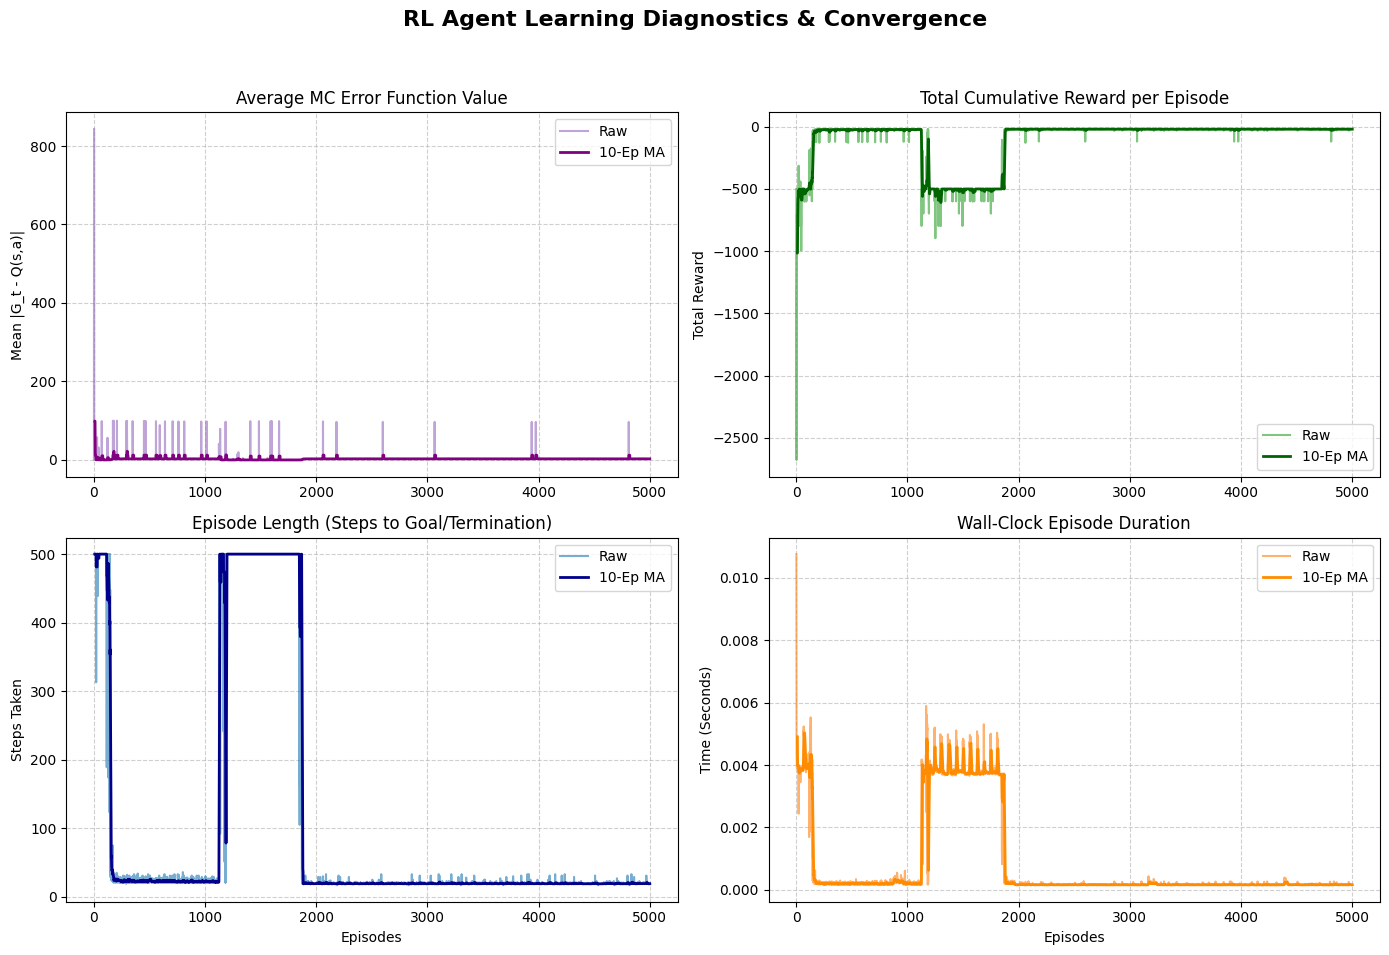

: 

In [ ]:
plot_learning_diagnostics(
    episode_avg_mc_error, episode_rewards, episode_lengths, episode_durations
)

## Comments MC Control with Epsilon Decay

We can see that the Agent converges fast and there is minimal fluctuations on our MC Error. Perfect! This is because once our agent gained sufficient experience, it stopped exploring. What it means literally is that once it found a good path, it stopped being "adventurous" and jumping off the cliff everytime!


#### Convergence Time

Let's see how long it took us to achieve convergence!

In [22]:
MC_Diff_Threshold = 0.001

for i in range(len(episode_avg_mc_error)):
    if episode_avg_mc_error[i] < MC_Diff_Threshold:
        print(f"Convergence achieved at episode {i + 1} with Avg MC Error: {episode_avg_mc_error[i]:.4f}")
        break

Convergence achieved at episode 495 with Avg MC Error: 0.0004


### Convergence
MC Error Threshold of 0.001 is achieved at around episode 70-100 with Avg MC Error less than 0.001. 

This means, our agent is "good enough" after 70-100 itterations. After that point, the difference between current policy and updated policy accumulates to negligible icrease/decrese in rewards - we have a sufficiently good station-action-value table (q-table).